In [ ]:
import numpy as np
import mne
import matplotlib.pyplot as plt

from eeglib import eegprep
from configs import FS, DIR, EPOCH_RANGE, CH_SET

# set logging level
mne.set_log_level('ERROR')

In [ ]:
filename = 'S14_S2.fif' #select the file to visualize

proc_before_ins, proc_after_ins, ica_before_ins, ica_after_ins = eegprep.preprocessing_pipeline(
    load_path=DIR['WORK']+'data/.fif/'+filename,
    ch_types='all',
    notch_freq=50,
    bandpass_param=[(0.2, 3), 2],
    average_ref=False,
    apply_asr=False,
    resampling_freq=FS['EEG_PP'],
    ica_param=[60, 'fastica'],
    emg_threshold=0.8,
    eog_threshold=0.8,
    remove_bad_channels=True,
    csd=True,
    save_path=None
)
print ("-"*40)

In [57]:
# reset ica instance
proc_before = proc_before_ins.copy()
proc_after = proc_after_ins.copy() 
ica_before = ica_before_ins.copy() 
ica_after = ica_after_ins.copy()

In [ ]:
event_ids = dict(me_st=11, me_s=12, r=13, mi_s_st=21, mi_s_s=22, r_s=23, mi_st_st=31, mi_st_s=32, r_st=33)
time_range = (-2, 5)

proc_eog_out = proc_before.copy()

event_info = eegprep.get_event_info(proc_eog_out.copy(), filetype='.fif')

epoch_eog_out = mne.Epochs(
                    proc_eog_out.copy(),
                    event_info,
                    picks=['eeg', 'csd'],
                    event_id=event_ids,
                    tmin=time_range[0],
                    tmax=time_range[1],
                    baseline=(-2, 0),
                )

In [ ]:
threshold_score = 0.8

eog_idx_vEOG, scores_vEOG = ica_before.find_bads_eog(proc_before, ch_name='vEOG', measure='correlation', threshold=threshold_score)
eog_idx_hEOG, scores_hEOG = ica_before.find_bads_eog(proc_before, ch_name='hEOG', measure='correlation', threshold=threshold_score)

print ([eog_idx_vEOG, eog_idx_hEOG])

emg_idx, scores_emg = ica_before.find_bads_muscle(proc_before, threshold=threshold_score)
print (emg_idx)

artifact_idx = list(set(eog_idx_vEOG + eog_idx_hEOG + emg_idx))

[[0], []]
[6, 13, 14, 17, 19, 20, 21, 24, 25, 27, 29, 37, 40, 44]


Plotting for task: me_st, Event ID: 11, Sample: 63064


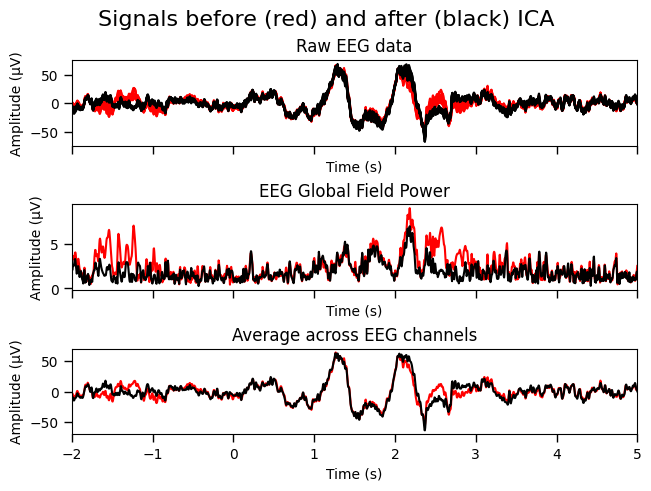

Plotting for task: me_s, Event ID: 12, Sample: 203062


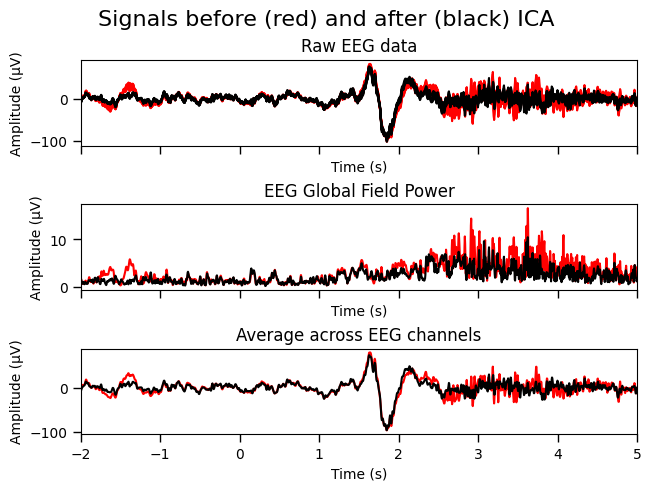

Plotting for task: r, Event ID: 13, Sample: 105064


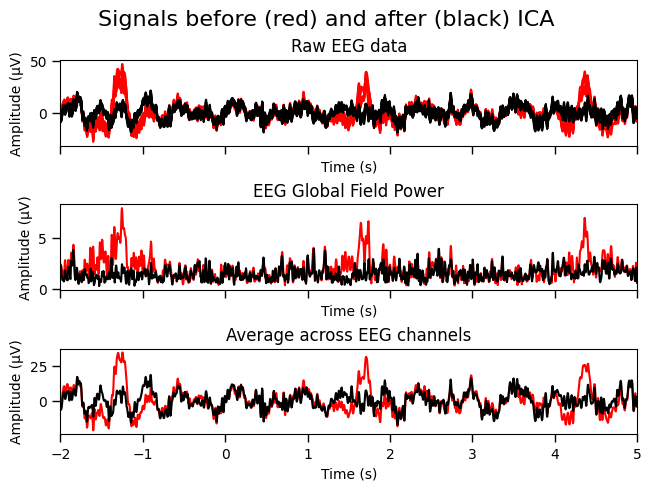

Plotting for task: mi_s_st, Event ID: 21, Sample: 276818


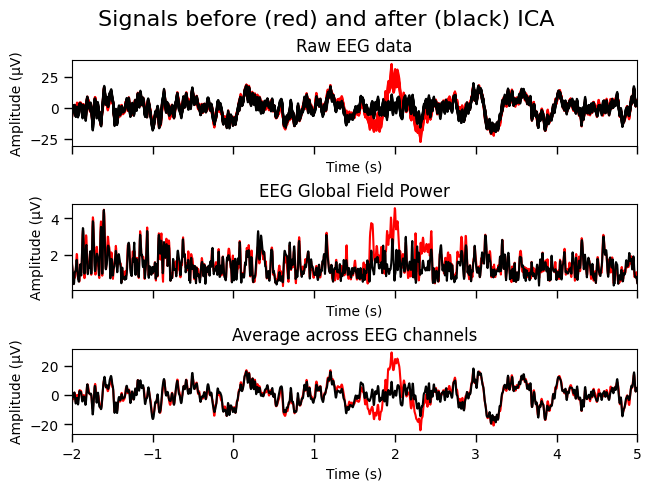

Plotting for task: mi_s_s, Event ID: 22, Sample: 332809


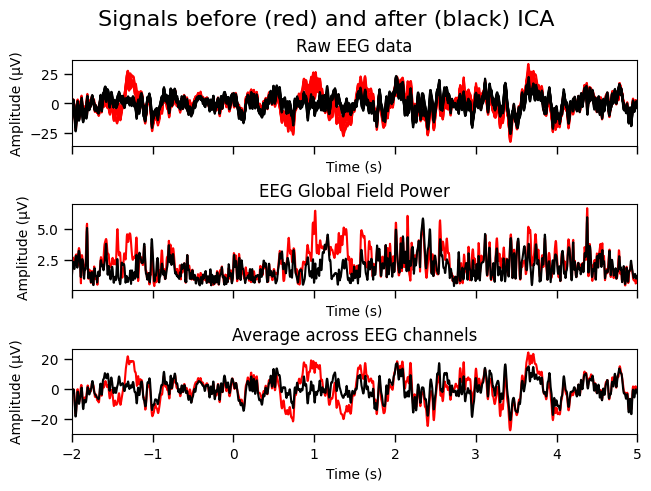

Plotting for task: r_s, Event ID: 23, Sample: 306821


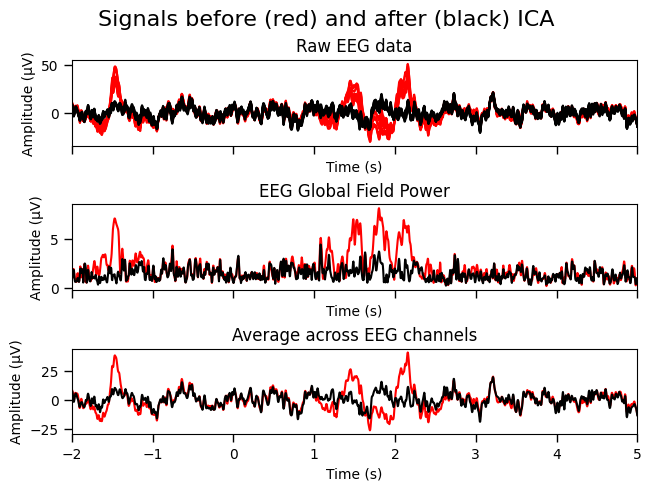

Plotting for task: mi_st_st, Event ID: 31, Sample: 553309


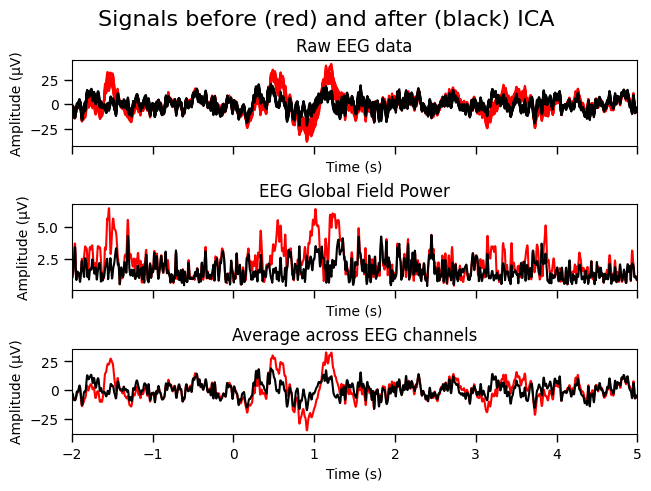

Plotting for task: mi_st_s, Event ID: 32, Sample: 537317


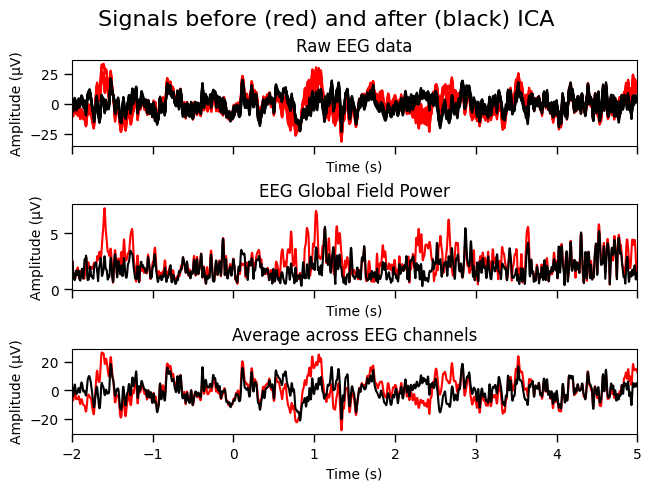

Plotting for task: r_st, Event ID: 33, Sample: 491317


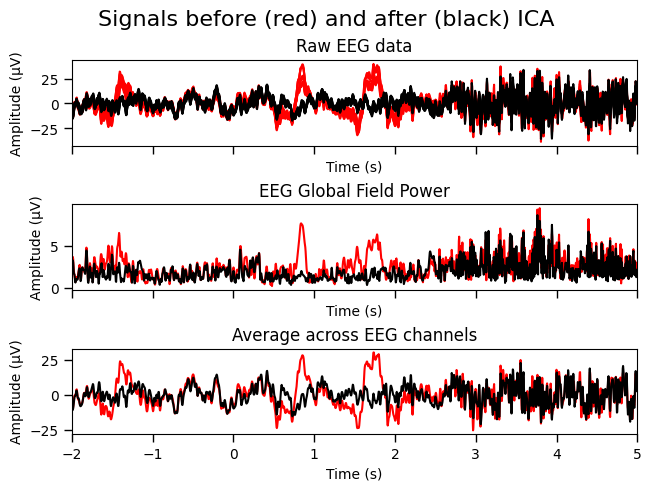

In [ ]:
import random

# Define parameters
tmin, tmax = -2, 5
sfreq = proc_before.info['sfreq']

# Get events from the raw object
events, event_id_map = mne.events_from_annotations(proc_before)

events = epoch_eog_out.events

for task_name, task_id in event_ids.items():
    # Find all sample indices for this task
    # events is an array where column 0 is sample index and column 2 is event id
    task_events = events[events[:, 2] == task_id]
    
    if len(task_events) == 0:
        print(f"No events found for task: {task_name} (ID: {task_id})")
        continue
        
    # Randomly pick one event index (sample number)
    chosen_event = random.choice(task_events)
    event_idx = chosen_event[0]
    
    print(f"Plotting for task: {task_name}, Event ID: {task_id}, Sample: {event_idx}")

    # Calculate start and stop samples
    start_samp = int(event_idx + tmin * sfreq)
    stop_samp = int(event_idx + tmax * sfreq)

    # Plot overlay
    # MNE plot_overlay usually uses red for original and black for cleaned signals by default
    # We create a new figure for each task
    overlay_fig = ica_before.plot_overlay(proc_before, exclude=artifact_idx, start=start_samp, stop=stop_samp, picks=CH_SET['LLC'], show=False)

    # Loop through all axes
    for ax in overlay_fig.axes:
        # 1. Adjust time axis to be relative to the event (0s at event_idx)
        lines = ax.get_lines()
        if len(lines) > 0:
            for line in lines:
                y_data = line.get_ydata()
                # Generate new x-axis values from tmin to tmax
                new_x = np.linspace(tmin, tmax, len(y_data))
                line.set_xdata(new_x)
                
        ax.set_xlim(tmin, tmax)
        ax.set_xlabel("Time (s)")

        # 2. Set y-label and its unit
        # Assuming unit is Volts (V)
        ax.set_ylabel(f"Amplitude (\u00b5V)") 
        # Ensure axis spines are visible
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')

        # Ensure ticks are visible
        ax.tick_params(axis='both', colors='black', direction='out', length=6, width=1)

    overlay_fig.suptitle("Signals before (red) and after (black) ICA", fontsize=16)

    overlay_fig.savefig(f"ica_image/{task_name}.png", dpi=300)

    plt.show()